#### 0) Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

#### 1) Configurations

In [2]:
output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

# Load portfolio returns from Notebook 5
df_port = pd.read_parquet(output_dir / "portfolio_returns.parquet")
returns = df_port['Portfolio'].values

#### 2) Bootstrap Monte Carlo Simulation

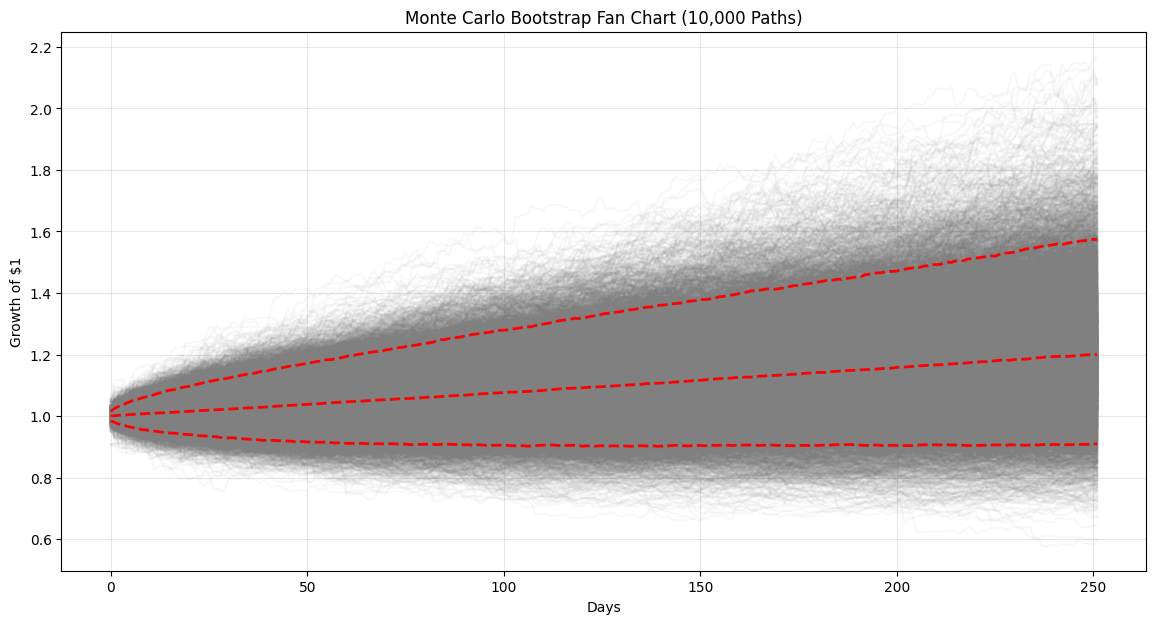

In [5]:
# 1000 independent simulations of portfolio's performance over 252 day horizon by resampling historical daily returns with replacement

np.random.seed(42) # for reproducibility
n_paths = 10000
n_days = 252

sim_results = np.zeros((n_days, n_paths)) # Initialize 2D array to store MC sim results

for i in range(n_paths):
    # Bootstrap returns with replacement
    sampled_returns = np.random.choice(returns, size=n_days, replace=True)
    sim_results[:, i] = (1 + sampled_returns).cumprod()


# plot fan chart
plt.figure(figsize=(14, 7))
plt.plot(sim_results, color='gray', alpha=0.05)
plt.plot(np.percentile(sim_results, [5, 50, 95], axis=1).T, color='red', linestyle='--', linewidth=2)
plt.title("Monte Carlo Bootstrap Fan Chart (10,000 Paths)")
plt.ylabel("Growth of $1")
plt.xlabel("Days")
plt.grid(alpha=0.3)
plt.show()

# Export Monte Carlo Stats
final_returns = sim_results[-1, :]
mc_summary = {
    "5th Percentile": np.percentile(final_returns, 5),
    "Median": np.percentile(final_returns, 50),
    "95th Percentile": np.percentile(final_returns, 95),
    "Prob of Positive Return": (final_returns > 1).mean()
}
pd.DataFrame([mc_summary]).to_parquet(output_dir / "monte_carlo_results.parquet")

#### 3) Stress Testing Engine

In [8]:
stress_windows = {
    "COVID" : ("2020-02-19", "2020-03-23"),
    "2022 Rate Hike" : ("2022-01-01", "2022-12-31"),
    "2015 China Devaluation" : ("2015-08-11", "2015-08-25"),
}

stress_results = {}

for name, (start, end) in stress_windows.items():
    mask = (df_port.index >= start) & (df_port.index <= end)
    period_ret = df_port.loc[mask, 'Portfolio']
    
    stress_results[name] = {
        "Total Return": (1 + period_ret).prod() - 1,
        "Max Drawdown": ( (1+period_ret).cumprod() / (1+period_ret).cumprod().cummax() - 1 ).min(),
        "Volatility": period_ret.std() * np.sqrt(252)
    }

df_stress = pd.DataFrame(stress_results).T
df_stress.to_parquet(output_dir / "stress_test_summary.parquet")

print("Stress Test Summary (Performance during historical regime shifts):")
print(df_stress)

Stress Test Summary (Performance during historical regime shifts):
                        Total Return  Max Drawdown  Volatility
COVID                      -0.154084     -0.171815    0.296341
2022 Rate Hike             -0.157951     -0.190759    0.118246
2015 China Devaluation     -0.061814     -0.065650    0.170513


#### 4) Visualize Stress Performance

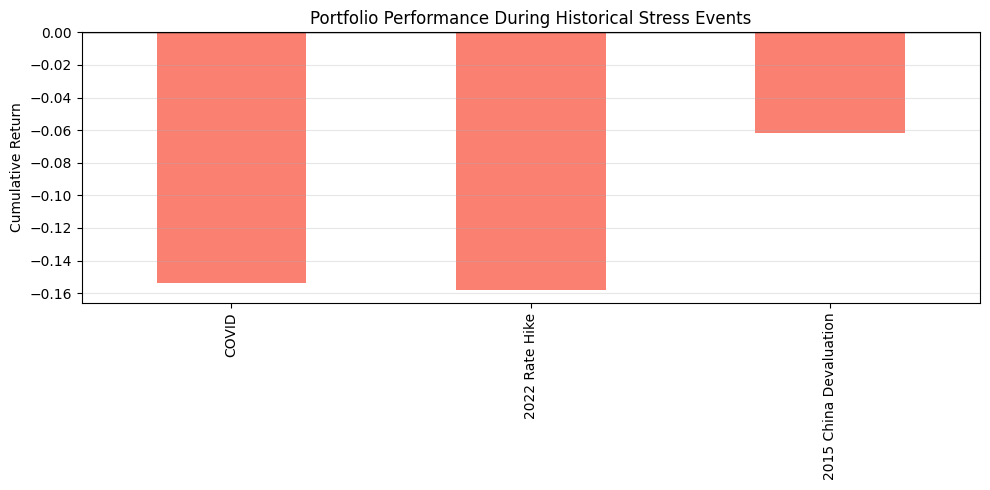

In [9]:
df_stress['Total Return'].plot(kind='bar', color='salmon', figsize=(10, 5))
plt.title("Portfolio Performance During Historical Stress Events")
plt.ylabel("Cumulative Return")
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 5) Distributions

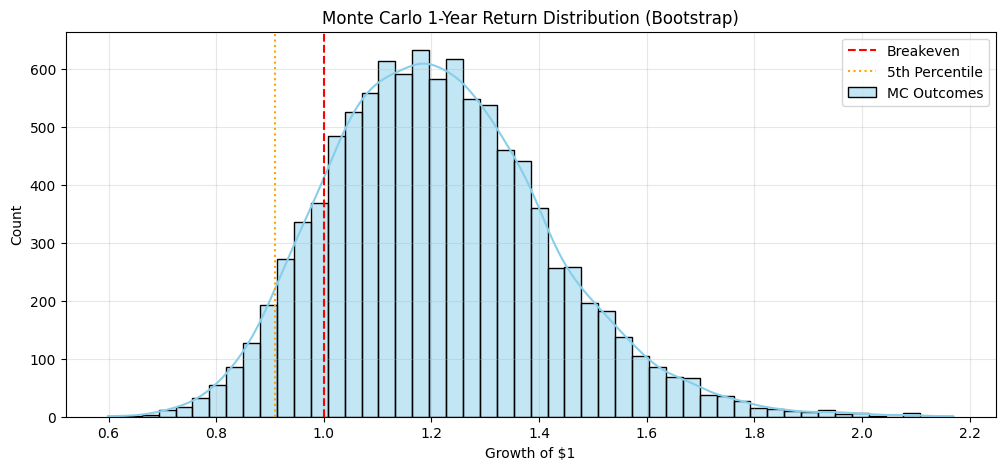

C:\Users\Hassa\AppData\Local\Temp\ipykernel_32328\1622144282.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_dist, x='Event', y='Return', palette='muted', inner='quartile')


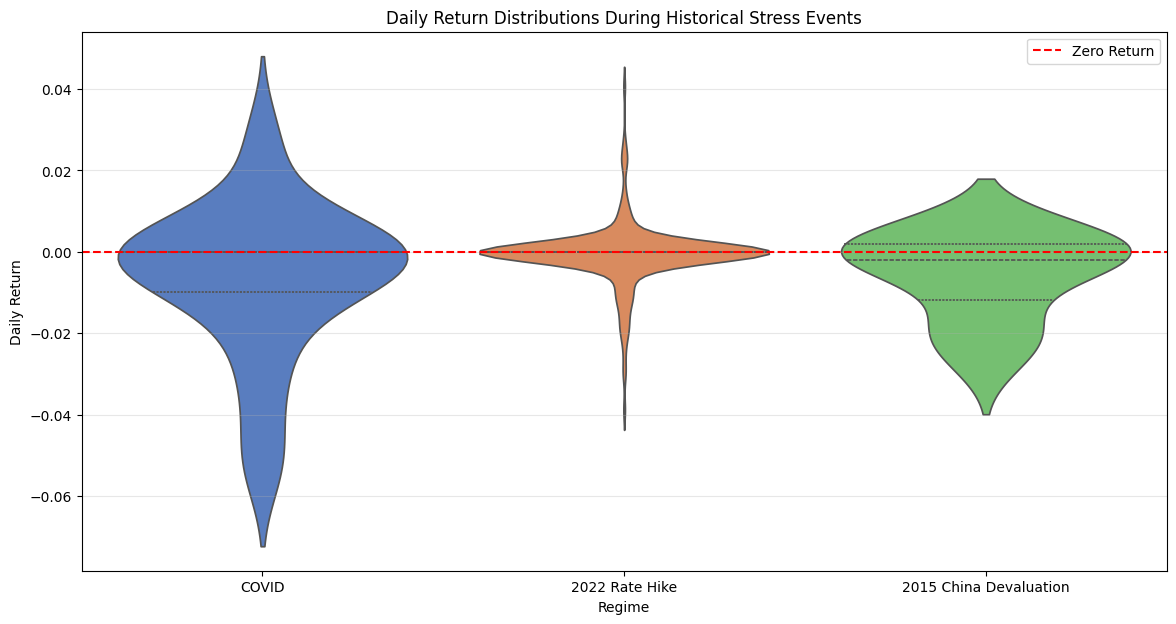

In [14]:
# 1. Monte Carlo Distribution
plt.figure(figsize=(12, 5))
sns.histplot(final_returns, bins=50, kde=True, color='skyblue', label='MC Outcomes')
plt.axvline(1.0, color='red', linestyle='--', label='Breakeven')
plt.axvline(np.percentile(final_returns, 5), color='orange', linestyle=':', label='5th Percentile')
plt.title("Monte Carlo 1-Year Return Distribution (Bootstrap)")
plt.xlabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Prepare a long-format DataFrame for categorical plotting
all_stress_returns = []

for name, (start, end) in stress_windows.items():
    mask = (df_port.index >= start) & (df_port.index <= end)
    period_returns = df_port.loc[mask, 'Portfolio'].copy()
    
    temp_df = period_returns.to_frame(name='Return')
    temp_df['Event'] = name
    all_stress_returns.append(temp_df)

df_dist = pd.concat(all_stress_returns)

# Plotting the distributions
plt.figure(figsize=(14, 7))
sns.violinplot(data=df_dist, x='Event', y='Return', palette='muted', inner='quartile')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Return')
plt.title("Daily Return Distributions During Historical Stress Events")
plt.ylabel("Daily Return")
plt.xlabel("Regime")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#### 6) Summary

In [15]:
print("--- STRATEGY ROBUSTNESS REPORT ---")
print(f"Median Expected 1-Year Outcome: {mc_summary['Median']:.2%}")
print(f"Prob of Profit in Random Walk: {mc_summary['Prob of Positive Return']:.2%}")
print("\nWorst Case Scenario (5th Percentile):")
print(f"Final Value: ${mc_summary['5th Percentile']:.2f}")
print("\nStress Test Observations:")
print(f"Best Resilience Window: {df_stress['Total Return'].idxmax()}")
print(f"Worst Resilience Window: {df_stress['Total Return'].idxmin()}")

--- STRATEGY ROBUSTNESS REPORT ---
Median Expected 1-Year Outcome: 120.02%
Prob of Profit in Random Walk: 85.89%

Worst Case Scenario (5th Percentile):
Final Value: $0.91

Stress Test Observations:
Best Resilience Window: 2015 China Devaluation
Worst Resilience Window: 2022 Rate Hike
